# Imports

- **Replace Null Values in Age column**

### 4- Handle Outliers

- **Check for Outliers**

In [4]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Chk datatype

In [7]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [8]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [9]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [10]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [11]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype('category')


In [12]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [13]:
df.shape[0]

891

In [14]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [15]:
median_1 = df['Age'].median()
df['Age'] = df['Age'].fillna(median_1, inplace=True)


In [16]:
df.dropna(subset=['Embarked'], inplace= True)


In [17]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,687.00000,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.27784,0.0


In [18]:
pip install matplotlib 
pip install seaborn  
pip install plotly

SyntaxError: invalid syntax (2135438036.py, line 1)

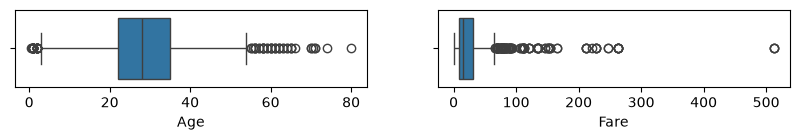

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(len(num_cols)*5,1))
for i,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h')

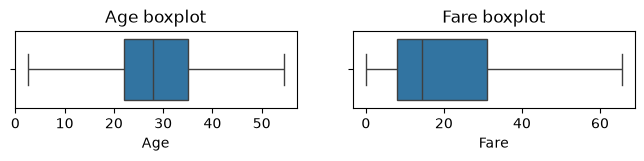

In [28]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols  =  df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} boxplot")



In [25]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    # print(lower_fence)
    lower_outliers = df[   df[col] < lower_fence    ][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)



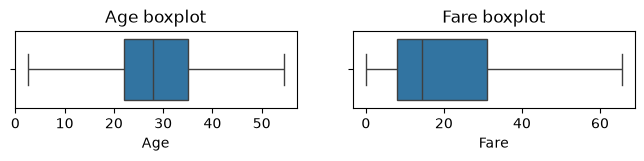

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols  =  df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} boxplot")



In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
def remove_duplicate(df, subset_cols= None,keep_stratgy = "first"):
    
    return (df.drop_duplicates(subset=subset_cols, keep=keep_stratgy).reset_index(drop = True))

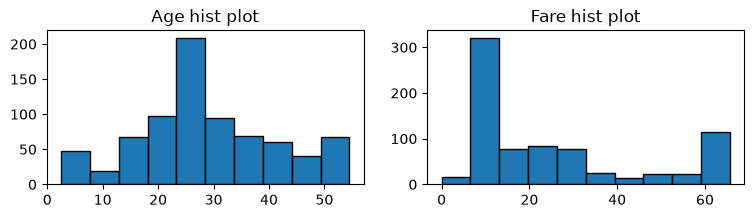

In [ ]:
def hist_plot(num_cols):
    plt.figure(figsize=(9,2))
    for i,col in enumerate(num_cols):
        plt.subplot(1,2,i+1)
        plt.hist(df[col], edgecolor='black')
        plt.title(f"{col} hist plot")
    return plt.show()
hist_plot(num_cols)

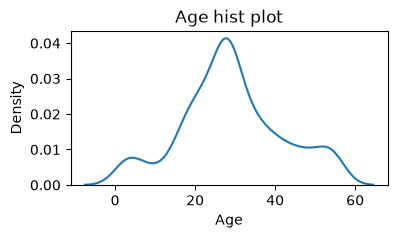

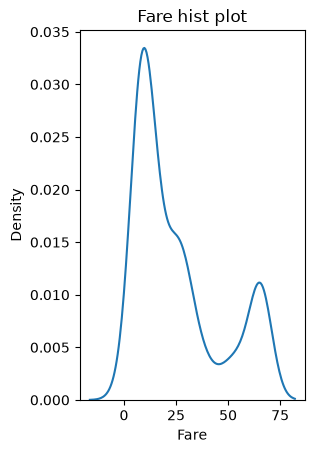

In [ ]:
plt.figure(figsize=(9,2))
for i,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist plot")
    plt.show()

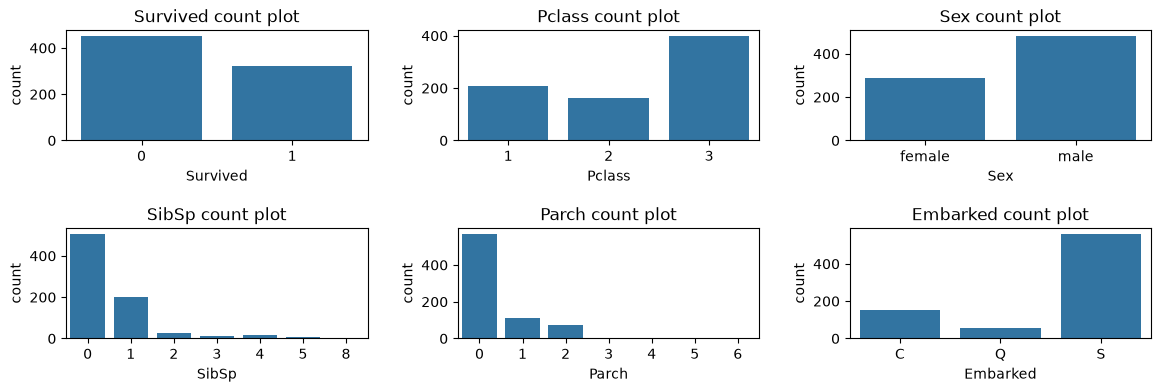

In [ ]:
cat_cols = df.select_dtypes('category').columns
plt.figure(figsize=(14,4))
for i,col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col,data=df)
    plt.title(f"{col} count plot")
plt.subplots_adjust(hspace=0.8,wspace=0.3)

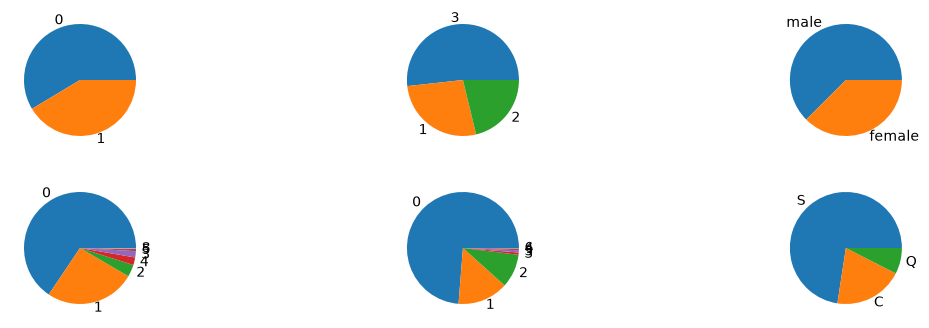

In [ ]:
unique = df['Survived'].value_counts()
count = unique.values
count
categories = unique.index
cat_cols = df.select_dtypes('category').columns
plt.figure(figsize=(14,4))
for i,col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count,labels=categories)

In [ ]:
import plotly.express as px
fig = px.pie(df, names = 'Survived',
title="<b>Survived</b>",
color_discrete_sequence=px.colors.qualitative.Pastel,
hole=0.7,

)
fig.update_layout(annotations = [dict(text="Survived"),font_size=20,x=0.5,y=0.5,showarrow=False])

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3965740511.py, line 8)

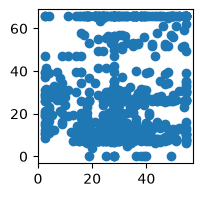

In [ ]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'],df['Fare'])

In [ ]:
sns.pairplot(df)

NameError: name 'sns' is not defined

<Axes: >

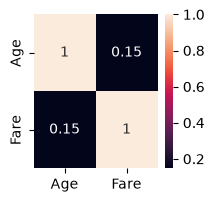

In [ ]:
corr = df[num_cols].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)